<a href="https://colab.research.google.com/github/jrangelg/Artificial-intelligence/blob/main/Caso1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install pyspark yfinance tensorflow scikit-learn statsmodels

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


+-------------------+----------------+------------------+
|       ('Date', '')|('usd', 'COP=X')|   ('oil', 'CL=F')|
+-------------------+----------------+------------------+
|2015-01-02 00:00:00|          2375.0|52.689998626708984|
|2015-01-05 00:00:00|          2430.0|50.040000915527344|
|2015-01-06 00:00:00|          2448.0| 47.93000030517578|
|2015-01-07 00:00:00|          2428.0|48.650001525878906|
|2015-01-08 00:00:00|          2389.0|48.790000915527344|
+-------------------+----------------+------------------+
only showing top 5 rows


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/

Epoch 1/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0361
Epoch 2/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0027
Epoch 3/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0014
Epoch 4/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0013
Epoch 5/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0013
Epoch 6/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0012
Epoch 7/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0012
Epoch 8/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0013
Epoch 9/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0013
Epoch 10/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0013
Epoch 1/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0217
Epoch 2/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0027
Epoch 3/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0017
Epoch 4/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0013
Epoch 5/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0012
Epoch 6/1

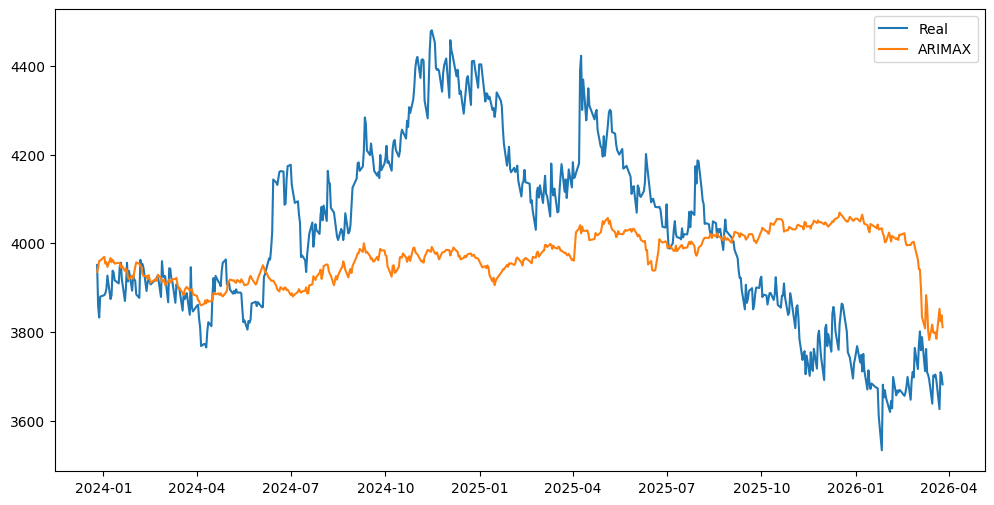

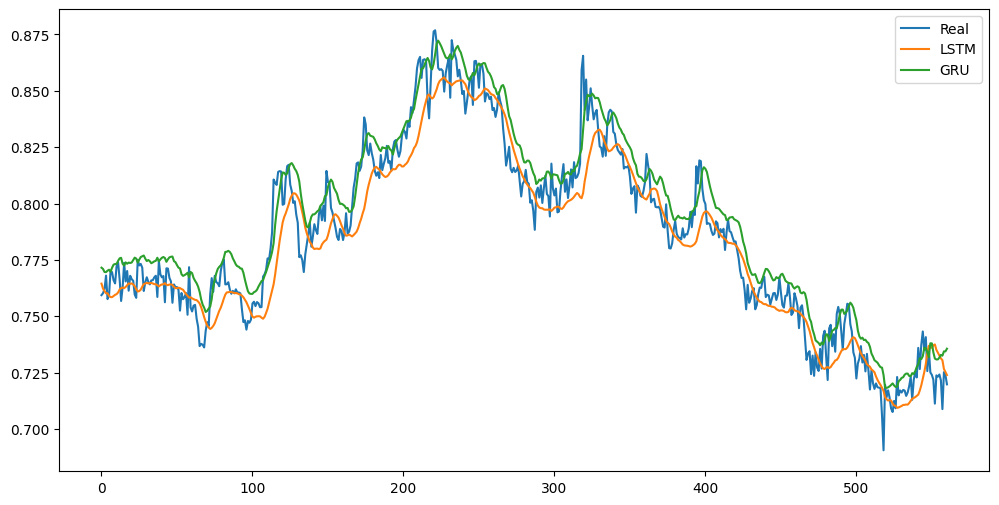

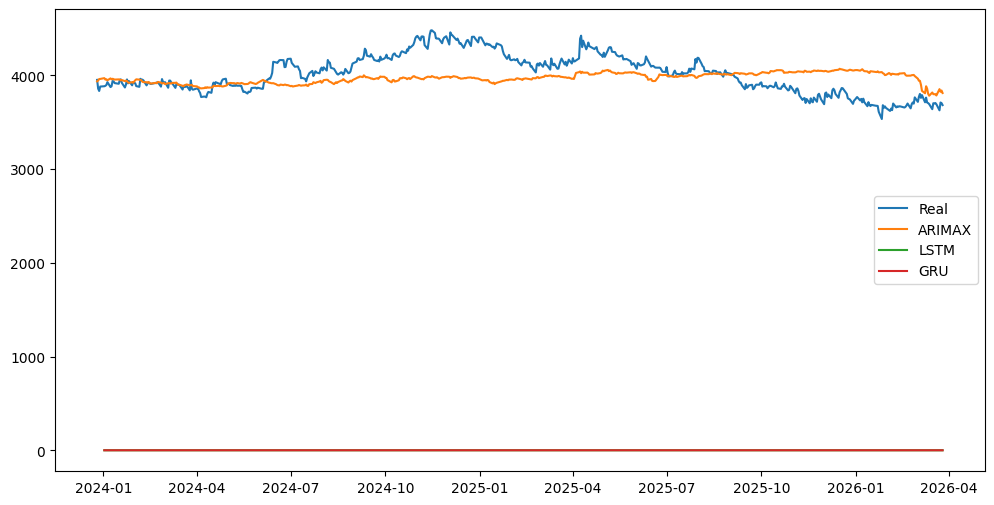

In [11]:
!pip -q install yfinance pyspark tensorflow scikit-learn statsmodels

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense

from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("FX_Model").getOrCreate()

usd_cop = yf.download("COP=X", start="2015-01-01", auto_adjust=False)
oil = yf.download("CL=F", start="2015-01-01", auto_adjust=False)

usd = usd_cop[["Close"]].rename(columns={"Close": "usd"})
oil = oil[["Close"]].rename(columns={"Close": "oil"})

df = usd.join(oil, how="inner").dropna()

spark_df = spark.createDataFrame(df.reset_index())
spark_df.show(5)

train_size = int(len(df)*0.8)
train = df.iloc[:train_size]
test = df.iloc[train_size:]

model = SARIMAX(train["usd"], exog=train[["oil"]], order=(1,1,1))
results = model.fit(disp=False)

pred_arimax = results.predict(
    start=len(train),
    end=len(df)-1,
    exog=test[["oil"]]
)

scaler = MinMaxScaler()
scaled = scaler.fit_transform(df)

def create_sequences(data, seq_len=20):
    X, y = [], []
    for i in range(len(data)-seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len,0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled)

split = int(len(X)*0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

lstm = Sequential([
    LSTM(50, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1)
])

lstm.compile(optimizer="adam", loss="mse")
lstm.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

gru = Sequential([
    GRU(50, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1)
])

gru.compile(optimizer="adam", loss="mse")
gru.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

lstm_pred = lstm.predict(X_test)
gru_pred = gru.predict(X_test)

def metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return rmse, mae

print("ARIMAX:", metrics(test["usd"], pred_arimax))
print("LSTM:", metrics(y_test, lstm_pred))
print("GRU:", metrics(y_test, gru_pred))

plt.figure(figsize=(12,6))
plt.plot(test.index, test["usd"], label="Real")
plt.plot(test.index, pred_arimax, label="ARIMAX")
plt.legend()
plt.show()

plt.figure(figsize=(12,6))
plt.plot(y_test, label="Real")
plt.plot(lstm_pred, label="LSTM")
plt.plot(gru_pred, label="GRU")
plt.legend()
plt.show()

plt.figure(figsize=(12,6))
plt.plot(test.index, test["usd"], label="Real")
plt.plot(test.index, pred_arimax, label="ARIMAX")

dl_index = test.index[-len(lstm_pred):]
plt.plot(dl_index, lstm_pred, label="LSTM")
plt.plot(dl_index, gru_pred, label="GRU")

plt.legend()
plt.show()